In [1]:
from mp_api.client import MPRester
from pymatgen.core import Structure
from pymatgen.core import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import numpy as np
from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

/Users/elyssahofgard/opt/miniconda3/envs/powderxrd/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Given a list of two theta values and intensities, the function creates a powder pattern of uniform length by treating each peak as a Gaussian with some standard deviation. 

In [12]:
def gen_powder_pattern(tt, intensities, min_2theta=0, max_2theta=90, length=5000, sigma=0.25):
    """
    generates a powder pattern of uniform length and finite peak width with Gaussian shape
    Following pymatgen conventions https://pymatgen.org/pymatgen.analysis.diffraction.xrd.html
    """
    lnx = np.linspace(min_2theta,max_2theta, length)
    pdf = np.zeros(shape=lnx.shape)
    for pos, height in zip(tt, intensities):
        pdf +=height*(stats.norm.pdf(lnx, pos, sigma))
    # normalizing, might not be necessary
    return lnx, pdf/np.max(pdf)

#### Example Use

In [6]:
# get a material from Materials Project

# silicon (MPRester() reads your key from the MP_API_KEY environment variable)
mat_id = "mp-149"
with MPRester() as mpr:
    si = mpr.summary.search(material_ids = ["mp-149"],fields=['structure','formula_pretty','symmetry'])[0]

/Users/elyssahofgard/opt/miniconda3/envs/powderxrd/lib/python3.9/site-packages/mp_api/client/mprester.py:182: UserWarning: mpcontribs-client not installed. Install the package to query MPContribs data, or construct pourbaix diagrams: 'pip install mpcontribs-client'
  warnings.warn(
Retrieving SummaryDoc documents: 100%|██████████| 1/1 [00:00<00:00, 35848.75it/s]


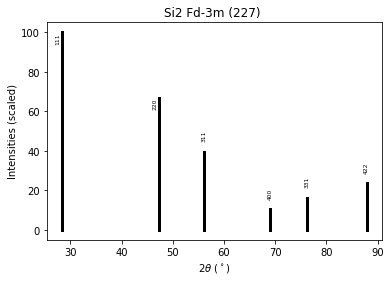

In [9]:
# get raw XRD pattern, note you can change the wavelength
# get primitive structure (note you could also do the conventional structure)
si_prim = si.structure.get_primitive_structure()
xrdc = XRDCalculator(wavelength='CuKa',symprec=1e-2,debye_waller_factors=None)
xrdc_plot = xrdc.plot_structures([si_prim])

In [13]:
# now fit Gaussian to peaks to get fixed length pattern
xrdc_pattern = xrdc.get_pattern(si_prim).as_dict()
tt, fitted_pattern = gen_powder_pattern(xrdc_pattern['x'],xrdc_pattern['y'])

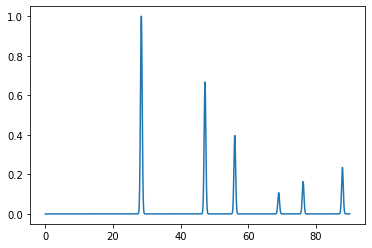

In [14]:
plt.plot(tt,fitted_pattern)

Note you can change the length of the array, sigma of the peaks, and the min/max two theta. I'm also not sure this is the best way to represent the pattern, but you can just feed it into your ML algorithm as a 1D array so it is convenient. 